# Drive Arbitration and Behavioral Phases

This notebook analyzes how hunger and curiosity interact through arbitration.

Primary focus:
- Maslow-like arbitration
- hunger gating curiosity
- exploration vs foraging
- phase-like behavioral transitions
- energy as a regime variable

The core claim is that behavioral regimes in `system_aw` emerge from continuous drive interaction rather than from hardcoded discrete modes.


In [1]:
from _bootstrap import setup_notebook

ROOT = setup_notebook()


## Why "Maslow-Like"?

The phrase *Maslow-like* should be read here as a modeling analogy, not as a claim of psychological fidelity.

What AXIS borrows from the broad intuition behind need hierarchies is simple:

- when survival pressure is low, exploration can remain behaviorally relevant
- when survival pressure rises, exploratory motives should lose priority

That intuition is useful for AXIS because we want a system in which hunger does not merely coexist with curiosity. We want hunger to be able to **gate** curiosity in a principled, continuous, inspectable way.

The important non-claim is that AXIS is **not** implementing Maslow's theory as a cognitive ontology. It is implementing a mathematically explicit priority relation between a primary drive (hunger) and a secondary drive (curiosity).


## What This Notebook Adds Beyond The Curiosity Notebook

The previous notebook established curiosity itself: novelty can create structured exploration gradients. This notebook asks a different question:

> What happens when curiosity and hunger both matter at the same time?

That question cannot be answered by looking at curiosity in isolation, because the observable behavior depends on how the system weighs immediate energetic pressure against exploratory opportunity.


In [2]:
import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display

from research.lib.plotting import bar_plot, lines_plot
from axis.systems.construction_kit.arbitration.weights import compute_maslow_weights

AW_SERIES_ROOT = ROOT / 'research' / 'workspaces' / 'system_aw-baseline' / 'series' / 'curiosity-arbitration'
AW_SUMMARY_PATH = AW_SERIES_ROOT / 'measurements' / 'series-summary.json'
AW_RESULTS_ROOT = AW_SERIES_ROOT / 'results'

SYSTEM_A_RUN_SUMMARY_LOG_PATH = ROOT / 'workspaces' / 'system_a-baseline' / 'measurements' / 'run_summary.log'

aw_summary = json.loads(AW_SUMMARY_PATH.read_text())
aw_experiments = {experiment['label']: experiment for experiment in aw_summary['experiments']}
selected_labels = ['aw-baseline', 'aw-sharp-maslow-switch', 'aw-soft-blended-drives']

aw_data = {}
for label in selected_labels:
    exp = aw_experiments[label]
    expid = exp['candidate_experiment_id']
    result_root = AW_RESULTS_ROOT / expid
    aw_data[label] = {
        'summary': exp,
        'config': json.loads((result_root / 'experiment_config.json').read_text()),
        'behavior_metrics': json.loads((result_root / 'runs' / 'run-0000' / 'behavior_metrics.json').read_text()),
        'episode_1': json.loads((result_root / 'runs' / 'run-0000' / 'episodes' / 'episode_0001.json').read_text()),
    }

system_a_log = SYSTEM_A_RUN_SUMMARY_LOG_PATH.read_text(encoding='utf-8')
summary_match = re.search(
    r"mean_steps=(?P<mean_steps>[0-9.]+)\s+death_rate=(?P<death_rate>[0-9.]+)\s+mean_final_vitality=(?P<mean_final_vitality>[0-9.]+)",
    system_a_log,
)
if summary_match is None:
    raise RuntimeError('Could not parse System A run summary log.')
system_a_summary = {k: float(v) for k, v in summary_match.groupdict().items()}

print('A+W series:', aw_summary['series_title'])
print('System A summary log:', SYSTEM_A_RUN_SUMMARY_LOG_PATH.relative_to(ROOT))


A+W series: System A+W Curiosity and Arbitration Series
System A summary log: workspaces/system_a-baseline/measurements/run_summary.log


## The Arbitration Equations

The two weights are:

$$
w_H(t) = w_H^{\text{base}} + (1 - w_H^{\text{base}}) \cdot d_H(t)^{\gamma}
$$

$$
w_C(t) = w_C^{\text{base}} \cdot (1 - d_H(t))^{\gamma}
$$

where:

- $d_H$ is hunger activation
- $w_H$ is the hunger weight
- $w_C$ is the curiosity weight
- $\gamma$ is `gating_sharpness`

The crucial structural consequence is:

- hunger weight rises with hunger activation
- curiosity weight falls with hunger activation
- the rate of that change depends on `gating_sharpness`

So there is no explicit mode switch. There is only a continuous weighting rule.


In [3]:
hunger_grid = [i / 100 for i in range(101)]
weight_rows = []
for label in selected_labels:
    arbitration_cfg = aw_data[label]['config']['system']['arbitration']
    for hunger_activation in hunger_grid:
        weights = compute_maslow_weights(
            hunger_activation,
            primary_weight_base=arbitration_cfg['hunger_weight_base'],
            secondary_weight_base=arbitration_cfg['curiosity_weight_base'],
            gating_sharpness=arbitration_cfg['gating_sharpness'],
        )
        weight_rows.append(
            {
                'label': label,
                'hunger_activation': hunger_activation,
                'hunger_weight': weights.hunger_weight,
                'curiosity_weight': weights.curiosity_weight,
            }
        )

weights_df = pd.DataFrame(weight_rows)
display(weights_df.head(12))


,label,hunger_activation,hunger_weight,curiosity_weight
0,aw-baseline,0.00,0.50000,0.50000
1,aw-baseline,0.01,0.50005,0.49005
2,aw-baseline,0.02,0.50020,0.48020
3,aw-baseline,0.03,0.50045,0.47045
4,aw-baseline,0.04,0.50080,0.46080
5,aw-baseline,0.05,0.50125,0.45125
6,aw-baseline,0.06,0.50180,0.44180
7,aw-baseline,0.07,0.50245,0.43245
8,aw-baseline,0.08,0.50320,0.42320
9,aw-baseline,0.09,0.50405,0.41405


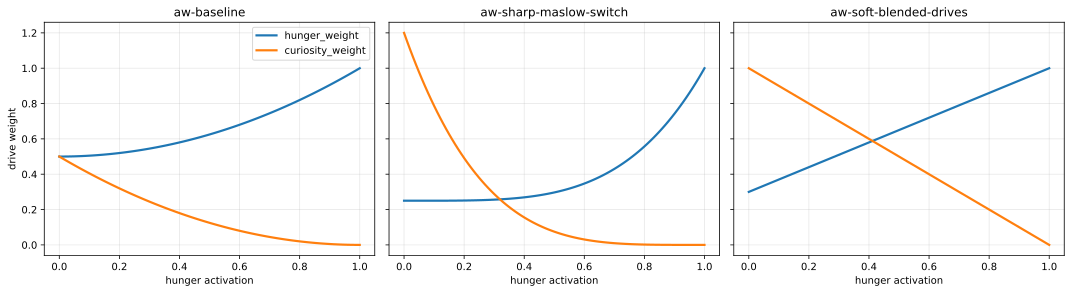

In [4]:
plt = __import__('matplotlib.pyplot').pyplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, label in zip(axes, selected_labels):
    subset = weights_df[weights_df['label'] == label]
    ax.plot(subset['hunger_activation'], subset['hunger_weight'], linewidth=2.2, label='hunger_weight')
    ax.plot(subset['hunger_activation'], subset['curiosity_weight'], linewidth=2.2, label='curiosity_weight')
    ax.set_title(label)
    ax.set_xlabel('hunger activation')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('drive weight')
axes[0].legend()
fig.tight_layout()


These curves already show why the notebook uses the phrase *phase-like* rather than *mode-based*.

There is no hardcoded state called `exploration mode` or `foraging mode`. Instead:

- low hunger leaves curiosity relatively influential
- medium hunger creates mixed regimes
- high hunger increasingly suppresses curiosity

That can *look* like mode switching in behavior, but the underlying mechanism is continuous.


## Why Energy Becomes A Regime Variable

In `system_aw`, energy is not just a bookkeeping variable. Through hunger activation, it changes the weighting geometry of the decision system.

That makes energy a **regime variable**:

- at high vitality, curiosity can materially shape movement
- at intermediate vitality, hunger and curiosity can both matter
- at low vitality, hunger increasingly dominates the arbitration outcome

The result is not a hand-authored phase controller. It is a continuous control system whose behavior becomes phase-like because the relative influence of the drives changes systematically.


In [5]:
phase_anchor_rows = []
for label in selected_labels:
    episode = aw_data[label]['episode_1']
    for target in [0.05, 0.30, 0.70]:
        best_step = min(
            episode['steps'],
            key=lambda step: abs(step['system_data']['decision_data']['hunger_drive']['activation'] - target),
        )
        dec = best_step['system_data']['decision_data']
        phase_anchor_rows.append(
            {
                'variant': label,
                'target_hunger_activation': target,
                'timestep': best_step['timestep'],
                'action': best_step['action'],
                'vitality_before': best_step['vitality_before'],
                'hunger_activation': dec['hunger_drive']['activation'],
                'curiosity_activation': dec['curiosity_drive']['activation'],
                'hunger_weight': dec['arbitration']['hunger_weight'],
                'curiosity_weight': dec['arbitration']['curiosity_weight'],
            }
        )

phase_anchor_df = pd.DataFrame(phase_anchor_rows)
display(phase_anchor_df)


,variant,target_hunger_activation,timestep,action,vitality_before,hunger_activation,curiosity_activation,hunger_weight,curiosity_weight
0,aw-baseline,0.05,5,down,0.9500,0.0500,0.500000,0.501250,0.451250
1,aw-baseline,0.30,30,right,0.7000,0.3000,0.481397,0.545000,0.245000
2,aw-baseline,0.70,140,down,0.2995,0.7005,0.500000,0.745350,0.044850
3,aw-sharp-maslow-switch,0.05,5,down,0.9500,0.0500,1.000000,0.250005,0.977407
4,aw-sharp-maslow-switch,0.30,30,right,0.7000,0.3000,0.962794,0.256075,0.288120
5,aw-sharp-maslow-switch,0.70,124,left,0.3010,0.6990,0.947818,0.429048,0.009850
6,aw-soft-blended-drives,0.05,5,down,0.9500,0.0500,1.000000,0.335000,0.950000
7,aw-soft-blended-drives,0.30,30,right,0.7000,0.3000,0.962794,0.510000,0.700000
8,aw-soft-blended-drives,0.70,357,right,0.2990,0.7010,0.987520,0.790700,0.299000


## Strong Trace Read: Baseline `system_aw`

We now inspect three actual points from the baseline trace that correspond roughly to:

- early low-hunger exploratory conditions
- a mid-hunger mixed regime
- a later high-hunger survival-dominated regime

This is where the phase-like interpretation becomes tangible.


In [6]:
baseline_episode = aw_data['aw-baseline']['episode_1']
baseline_indices = [5, 50, 150]
baseline_trace_rows = []
for idx in baseline_indices:
    step = baseline_episode['steps'][idx]
    dec = step['system_data']['decision_data']
    baseline_trace_rows.append(
        {
            'timestep': idx,
            'action': step['action'],
            'vitality_before': step['vitality_before'],
            'hunger_activation': dec['hunger_drive']['activation'],
            'curiosity_activation': dec['curiosity_drive']['activation'],
            'hunger_weight': dec['arbitration']['hunger_weight'],
            'curiosity_weight': dec['arbitration']['curiosity_weight'],
            'current_resource': dec['observation']['current']['resource'],
            'max_neighbor_resource': max(dec['observation'][d]['resource'] for d in ['up', 'down', 'left', 'right']),
        }
    )

baseline_trace_df = pd.DataFrame(baseline_trace_rows)
display(baseline_trace_df)


,timestep,action,vitality_before,hunger_activation,curiosity_activation,hunger_weight,curiosity_weight,current_resource,max_neighbor_resource
0,5,down,0.9500,0.0500,0.500000,0.501250,0.451250,0.0,0.0
1,50,right,0.6435,0.3565,0.476602,0.563546,0.207046,0.0,0.0
2,150,right,0.1995,0.8005,0.500000,0.820400,0.019900,0.0,0.0


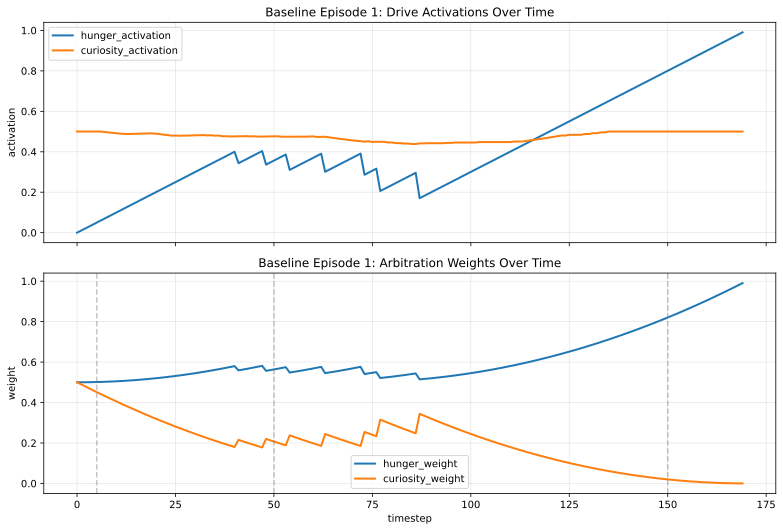

In [7]:
full_baseline_rows = []
for step in baseline_episode['steps']:
    dec = step['system_data']['decision_data']
    full_baseline_rows.append(
        {
            'timestep': step['timestep'],
            'vitality_before': step['vitality_before'],
            'hunger_activation': dec['hunger_drive']['activation'],
            'curiosity_activation': dec['curiosity_drive']['activation'],
            'hunger_weight': dec['arbitration']['hunger_weight'],
            'curiosity_weight': dec['arbitration']['curiosity_weight'],
            'action': step['action'],
        }
    )

full_baseline_df = pd.DataFrame(full_baseline_rows)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
axes[0].plot(full_baseline_df['timestep'], full_baseline_df['hunger_activation'], linewidth=2.0, label='hunger_activation')
axes[0].plot(full_baseline_df['timestep'], full_baseline_df['curiosity_activation'], linewidth=2.0, label='curiosity_activation')
axes[0].set_ylabel('activation')
axes[0].set_title('Baseline Episode 1: Drive Activations Over Time')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(full_baseline_df['timestep'], full_baseline_df['hunger_weight'], linewidth=2.0, label='hunger_weight')
axes[1].plot(full_baseline_df['timestep'], full_baseline_df['curiosity_weight'], linewidth=2.0, label='curiosity_weight')
for idx in baseline_indices:
    axes[1].axvline(idx, color='gray', linestyle='--', alpha=0.45)
axes[1].set_xlabel('timestep')
axes[1].set_ylabel('weight')
axes[1].set_title('Baseline Episode 1: Arbitration Weights Over Time')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()


This is the hybrid interpretation in its clearest form.

The weights change smoothly, but the resulting behavior can still be grouped into recognizable regimes:

- early: curiosity still has room to shape movement broadly
- middle: mixed regime, where exploratory and survival pressures coexist
- late: curiosity is not mathematically gone, but behavior becomes strongly hunger-shaped

So the phases are real at the behavioral level, even though they are not implemented as explicit finite states.


## Sharp Versus Soft Gating

The `aw-sharp-maslow-switch` and `aw-soft-blended-drives` variants are especially useful because they change not the existence of the two drives, but the *shape of the handoff* between them.


In [8]:
variant_trace_rows = []
for label in ['aw-sharp-maslow-switch', 'aw-soft-blended-drives']:
    episode = aw_data[label]['episode_1']
    for idx in [5, 50, 150]:
        if idx >= len(episode['steps']):
            continue
        step = episode['steps'][idx]
        dec = step['system_data']['decision_data']
        variant_trace_rows.append(
            {
                'variant': label,
                'timestep': idx,
                'action': step['action'],
                'vitality_before': step['vitality_before'],
                'hunger_activation': dec['hunger_drive']['activation'],
                'hunger_weight': dec['arbitration']['hunger_weight'],
                'curiosity_weight': dec['arbitration']['curiosity_weight'],
            }
        )

variant_trace_df = pd.DataFrame(variant_trace_rows)
display(variant_trace_df)


,variant,timestep,action,vitality_before,hunger_activation,hunger_weight,curiosity_weight
0,aw-sharp-maslow-switch,5,down,0.950,0.050,0.250005,0.977407
1,aw-sharp-maslow-switch,50,left,0.500,0.500,0.296875,0.075000
2,aw-sharp-maslow-switch,150,left,0.041,0.959,0.884360,0.000003
3,aw-soft-blended-drives,5,down,0.950,0.050,0.335000,0.950000
4,aw-soft-blended-drives,50,right,0.500,0.500,0.650000,0.500000
5,aw-soft-blended-drives,150,left,0.611,0.389,0.572300,0.611000


In [9]:
comparison_rows = []
for label in selected_labels:
    metrics = aw_data[label]['behavior_metrics']['system_specific_metrics']
    summary = aw_data[label]['summary']['run_summary']
    comparison_rows.append(
        {
            'variant': label,
            'curiosity_dominance_rate': metrics['system_aw_arbitration']['curiosity_dominance_rate'],
            'mean_hunger_weight': metrics['system_aw_arbitration']['mean_hunger_weight'],
            'mean_curiosity_weight': metrics['system_aw_arbitration']['mean_curiosity_weight'],
            'curiosity_led_move_rate': metrics['system_aw_behavior']['curiosity_led_move_rate'],
            'death_rate': summary['death_rate'],
            'mean_final_vitality': summary['mean_final_vitality'],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


,variant,curiosity_dominance_rate,mean_hunger_weight,mean_curiosity_weight,curiosity_led_move_rate,death_rate,mean_final_vitality
0,aw-baseline,0.000000,0.582850,0.231795,0.260540,0.62,0.23836
1,aw-sharp-maslow-switch,0.220089,0.311005,0.200184,0.524359,0.58,0.24496
2,aw-soft-blended-drives,0.310742,0.634745,0.521793,0.639841,0.70,0.14849


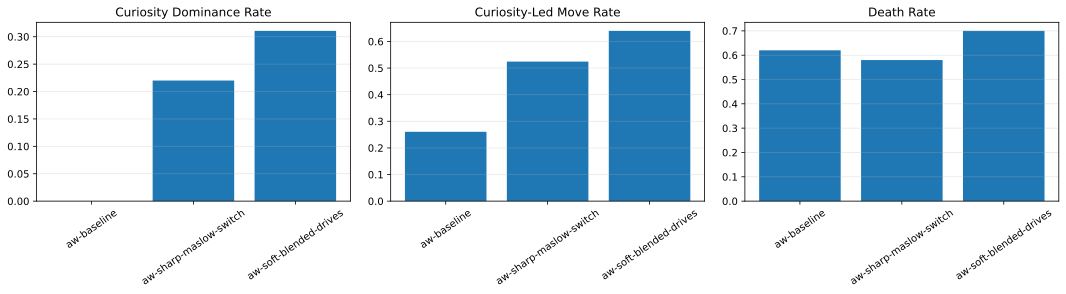

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].bar(comparison_df['variant'], comparison_df['curiosity_dominance_rate'])
axes[0].set_title('Curiosity Dominance Rate')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(comparison_df['variant'], comparison_df['curiosity_led_move_rate'])
axes[1].set_title('Curiosity-Led Move Rate')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(comparison_df['variant'], comparison_df['death_rate'])
axes[2].set_title('Death Rate')
axes[2].tick_params(axis='x', rotation=35)
axes[2].grid(True, axis='y', alpha=0.3)

fig.tight_layout()


The sharp/soft comparison makes the arbitration idea concrete.

- **sharp gating** keeps curiosity very strong at low hunger, but then suppresses it much more abruptly
- **soft blending** allows broader mixed regimes where both drives stay behaviorally relevant for longer

That changes not just abstract weights, but the shape of the resulting behavior.


## Why System A Cannot Show The Same Kind Of Regime Structure

System A can still display different outcomes across time, but not the same kind of drive-regime interaction, because it has only one drive.

That means there is no arbitration problem to solve in the first place.


In [11]:
system_a_vs_aw_df = pd.DataFrame(
    [
        {
            'system': 'system_a',
            'death_rate': system_a_summary['death_rate'],
            'mean_steps': system_a_summary['mean_steps'],
            'mean_final_vitality': system_a_summary['mean_final_vitality'],
            'has_drive_arbitration': False,
        },
        {
            'system': 'system_aw_baseline',
            'death_rate': aw_data['aw-baseline']['summary']['run_summary']['death_rate'],
            'mean_steps': aw_data['aw-baseline']['summary']['run_summary']['mean_steps'],
            'mean_final_vitality': aw_data['aw-baseline']['summary']['run_summary']['mean_final_vitality'],
            'has_drive_arbitration': True,
        },
    ]
)
display(system_a_vs_aw_df)


,system,death_rate,mean_steps,mean_final_vitality,has_drive_arbitration
0,system_a,0.72,241.00,0.22100,False
1,system_aw_baseline,0.62,293.16,0.23836,True


In [12]:
# Use the System A vs A+W comparison workspace as an external check on behavioral divergence.
comparison_002 = json.loads((ROOT / 'workspaces' / 'system_a_vs_system_aw' / 'series' / 'system-parameter-variations' / 'comparisons' / 'comparison-002.json').read_text())
comparison_summary = comparison_002['comparison_result']['summary']
comparison_summary_df = pd.DataFrame(
    [
        ('action_mismatch_rate_mean', comparison_summary['action_mismatch_rate']['mean']),
        ('mean_trajectory_distance', comparison_summary['mean_trajectory_distance']['mean']),
        ('mean_vitality_difference', comparison_summary['mean_vitality_difference']['mean']),
        ('reference_survival_rate', comparison_summary['reference_survival_rate']),
        ('candidate_survival_rate', comparison_summary['candidate_survival_rate']),
    ],
    columns=['comparison_metric', 'value'],
)
display(comparison_summary_df)


,comparison_metric,value
0,action_mismatch_rate_mean,0.779746
1,mean_trajectory_distance,10.654306
2,mean_vitality_difference,0.210685
3,reference_survival_rate,0.620000
4,candidate_survival_rate,0.720000


The contrast to System A matters conceptually.

System A can become more urgency-driven as energy falls, but that is still only one drive scaling its own action scores. It does not create a changing balance between exploratory and foraging pressures.

System A+W does.

That is why the regime structure in `system_aw` should not be reduced to "low energy means act differently". The important addition is that low energy reorders the relative priority between **two distinct motivational systems**.


## Closing Perspective

This notebook's core point is that phase-like behavior in `system_aw` is **emergent from continuous interaction**.

The system does not contain hardcoded modes like:

- `explore_mode`
- `forage_mode`
- `panic_mode`

Instead, it contains:

- a hunger activation function
- a curiosity activation function
- a continuous gating rule
- action score combination under those changing weights

That is enough to generate recognizable behavioral regimes.

So the right reading is not:

> the agent switches modes because the programmer told it to.

It is:

> the agent moves through different behavioral regimes because continuous drive interaction reshapes what kinds of actions are currently worth taking.
